<a href="https://colab.research.google.com/github/rudykenny21-glitch/123/blob/main/%E3%80%8C%E9%BB%91%E6%B4%9E%E6%9C%9F%E6%9C%AB%E4%BD%9C%E6%A5%AD%E6%9C%80%E5%BE%8C%E7%89%88%E6%9C%AC%E3%80%8D%E7%9A%84%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 安裝必要套件
!pip install -q gwosc gwpy

# 1. 下載事件數據（GW190425）
from gwosc import datasets
from gwpy.timeseries import TimeSeries

# 指定事件名稱（GW190425）
event_name = "GW190425"

# 取得事件 GPS 時間
gps = datasets.event_gps(event_name)
print(f"{event_name} GPS time:", gps)

# 下載原始 LIGO Livingston 儀器數據（2秒前到2秒後窗口）
strain = TimeSeries.fetch_open_data('L1', gps-2, gps+2, cache=True)
print(strain)  # 顯示數據基本訊息

/usr/local/lib/python3.12/dist-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


GW190425 GPS time: 1240215503.0
TimeSeries([-2.33834513e-19, -2.33877564e-19, -2.40204724e-19,
            ...,  3.76481395e-19,  3.66595870e-19,
             3.58546225e-19]
           unit: dimensionless,
           t0: 1240215501.0 s,
           dt: 0.000244140625 s,
           name: Strain,
           channel: None)


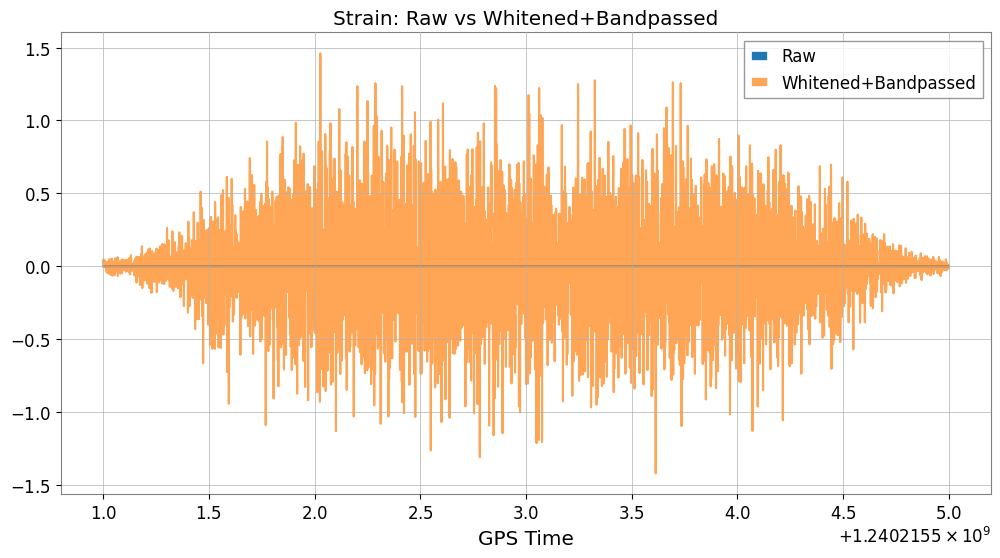

<Figure size 1000x500 with 0 Axes>

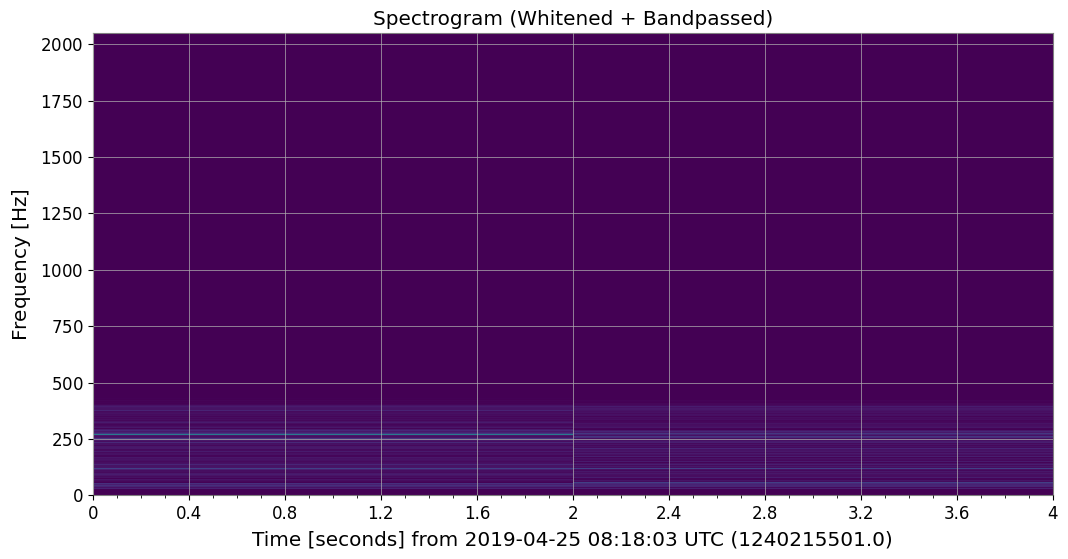

In [2]:
# Whitening 與 Bandpass
whitened = strain.whiten(fftlength=2, overlap=1)
bandpassed = whitened.bandpass(30, 400)

# 畫出原始 vs 處理後訊號
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(strain.times.value, strain.value, label="Raw")
plt.plot(bandpassed.times.value, bandpassed.value, label="Whitened+Bandpassed", alpha=0.7)
plt.legend()
plt.title("Strain: Raw vs Whitened+Bandpassed")
plt.xlabel("GPS Time")
plt.show()

# 畫出 Spectrogram
plt.figure(figsize=(10, 5))
specgram = bandpassed.spectrogram(fftlength=2, stride=2)
specgram.plot()
plt.title("Spectrogram (Whitened + Bandpassed)")
plt.show()

In [6]:
from gwosc.datasets import event_gps
from gwosc.api import fetch_event_json

# ==== 输入事件名称 ====
event_name = input("请输入事件名称（例如：GW150914, GW170817, GW190814）：")

try:
    # 获取事件 GPS 时间（验证事件是否存在）
    gps = event_gps(event_name)
    print(f"事件 {event_name} 的 GPS 时间：{gps}")

    # 从 GWOSC 提取事件 JSON 数据
    event_data = fetch_event_json(event_name)

    # 提取嵌套的事件数据
    events = event_data.get("events", {})
    if not events:
        raise KeyError("无法在 JSON 数据中找到 'events' 字段！")

    specific_event = None
    for key, value in events.items():
        if value.get("commonName") == event_name:  # 匹配事件名
            specific_event = value
            break

    if not specific_event:
        raise KeyError(f"未能从事件数据中找到匹配的具体事件：{event_name}")

    # 从具体事件中提取质量参数
    mass1 = specific_event.get("mass_1_source")
    mass2 = specific_event.get("mass_2_source")

    if not mass1 or not mass2:
        raise KeyError("未找到质量相关的参数（mass_1_source 和 mass_2_source）！")

    # 打印结果
    print(f"\n事件：{event_name}")
    print(f"质量1：{mass1} 太阳质量")
    print(f"质量2：{mass2} 太阳质量")

    # 模板和最低频率默认值
    approximant = "IMRPhenomD"
    f_lower = 20.0
    print(f"模板：{approximant}")
    print(f"最低频率：{f_lower} Hz")

except Exception as e:
    print(f"错误：{str(e)}")

请输入事件名称（例如：GW150914, GW170817, GW190814）：GW190425
事件 GW190425 的 GPS 时间：1240215503.0

事件：GW190425
质量1：2.1 太阳质量
质量2：1.3 太阳质量
模板：IMRPhenomD
最低频率：20.0 Hz


In [ ]:
# 安装必要套件（PyCBC 和相关工具）
!pip install -q pycbc lalsuite

# 作业 3：模拟波形并进行匹配
from pycbc.waveform import get_td_waveform
from pycbc.types import TimeSeries
from pycbc.psd import welch
from pycbc.filter import match
import numpy as np
import matplotlib.pyplot as plt

# 双星参数
mass1 = 36.0  # 第一颗天体质量（太阳质量）
mass2 = 29.0  # 第二颗天体质量（太阳质量）
approximant = 'IMRPhenomD'  # 模板类型
f_lower = 20.0  # 波形的最低频率
dt = 1.0 / 4096  # 采样间隔

# 生成理论波形
hp, _ = get_td_waveform(approximant=approximant,
                        mass1=mass1, mass2=mass2,
                        delta_t=dt, f_lower=f_lower)
print("Waveform generated.")

# ==== 数据格式转换 ====
# 将处理后的数据和模板波形转换为 PyCBC TimeSeries
min_len = min(len(hp), len(bandpassed))
template_array = np.array(hp[:min_len])
data_array = np.array(bandpassed.value[:min_len])

template_ts = TimeSeries(template_array, delta_t=dt)
data_ts = TimeSeries(data_array, delta_t=dt)

# 增大段长度以确保 PSD delta_f 与模板一致
seg_len = int(4.0 / dt)  # 使用 4 秒段长
psd = welch(data_ts, seg_len=seg_len, seg_stride=seg_len // 2)  # 计算 PSD

# 将模板和数据转换为频域，并强制保持 delta_f 一致
template_fs = template_ts.to_frequencyseries(delta_f=psd.delta_f)
data_fs = data_ts.to_frequencyseries(delta_f=psd.delta_f)

# ==== 匹配算法 ====
matchval = match(template_fs, data_fs, psd=psd, low_frequency_cutoff=f_lower)
print("Match value between data and template waveform:", matchval)

# ==== 可视化理论波形 ====
plt.figure(figsize=(12, 6))
plt.plot(hp.sample_times, hp, label="Template Inspiral Waveform")
plt.title("Inspiral waveform (PyCBC TaylorT4)")
plt.xlabel("Time [s]")
plt.ylabel("Strain")
plt.legend()
plt.show()

# ==== 输出双星合并相关信息 ====
total_mass = mass1 + mass2
print(f"Total Mass: {total_mass} solar masses")
print(f"Component masses: {mass1}, {mass2} solar masses")